# Set up the project environment

Before opening this notebook, run `./create_environment.sh` from the repository root, then run `conda activate tensor_dslab`. Launch your notebook frontend or select its Python kernel only after that environment is active. Environment creation and activation are explicit user actions outside the notebook; no code cell below invokes Conda, installs packages, or changes interpreters.

# Public DS20k Veto readout demonstration

This notebook demonstrates TensorDSLab's public in-memory readout API from already-binned photoelectron truth through digitized ADC codes. The `ds20k_veto()` values are a provisional demonstration profile, not an approved production calibration.

The workflow is intentionally explicit: verify the already-active interpreter and CPU boundary, construct semantic axes and a `Photoelectrons` field, compare manual and profile-based configuration, request all six readout products, inspect their contracts, visualize their relationships, and finish with a requested-only retention example.

The first Python cell reports the active executable and exact Python/PyTorch versions. Its ordinary device-unspecified tensor must land on CPU, which demonstrates the execution boundary without inspecting or selecting CUDA.

In [1]:
import platform
import sys

import torch

default_tensor = torch.empty(())
print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)
print("Default tensor device:", default_tensor.device)
assert platform.python_version() == "3.14.6"
assert torch.__version__.split("+", maxsplit=1)[0] == "2.13.0"
assert default_tensor.device.type == "cpu"

Python executable: /opt/miniconda3/envs/tensor_dslab/bin/python
Python version: 3.14.6
PyTorch version: 2.13.0
Default tensor device: cpu


## Supported public imports

The imports below come only from TensorCore's package root, TensorDSLab's package root, and the precise public profile module. Product classes are both request tokens and exact typed-lookup keys. Configuration records remain ordinary immutable values; `quantity(...)` and `quantities(...)` establish TensorDSLab's physical-unit boundary.

Matplotlib is a demo-only dependency. It is imported later at the visualization boundary and never enters TensorDSLab production.

In [2]:
%matplotlib inline
from dataclasses import replace

import torch
from tensor_core import NonnegativeFloat, PositiveInteger, Threefry4x32

from tensor_dslab import (
    AnalogWaveform,
    AnalogWaveformConfig,
    ChannelAxis,
    Charge,
    ChargeConfig,
    DarkCountConfig,
    DigitizedWaveform,
    DigitizedWaveformConfig,
    ExampleAxis,
    NoiseWaveform,
    NoiseWaveformConfig,
    Photoelectrons,
    PsdNoiseConfig,
    PureWaveform,
    PureWaveformConfig,
    ReadoutConfig,
    SampleAxis,
    VetoPduPulseConfig,
    WhiteNoiseConfig,
    quantities,
    quantity,
    simulate_readout,
)
from tensor_dslab.readout.profiles import ds20k_veto

## Construct already-binned photoelectron truth

`Photoelectrons` is the public ingress product. TensorDSLab does not parse detector files or bin upstream photon data here, so this demo constructs a small deterministic source inline. Four assignments place exactly `1`, `2`, `3`, and `4` upstream PE at separated sample indices. No random source construction or ambient RNG state is involved.

The semantic axes describe two examples, four named Veto channels, and 5000 samples at a requested 2 ns period: an exclusive 10000 ns window. The deposits land at 200, 2600, 5000, and 7400 ns in example 0, channel `veto-0`, which is the trace visualized below. The tensor uses `torch.int64` nonnegative counts and its shape follows the exact axis order. The source is created explicitly on CPU; the demo never inspects or selects an accelerator.

In [3]:
axes = (
    ExampleAxis(count=2),
    ChannelAxis(labels=("veto-0", "veto-1", "veto-2", "veto-3")),
    SampleAxis.from_period(period=quantity(2.0, "ns"), count=5000),
)
shape = tuple(axis.size for axis in axes)
counts = torch.zeros(shape, dtype=torch.int64, device="cpu")
counts[0, 0, 100] = 1
counts[0, 0, 1300] = 2
counts[0, 0, 2500] = 3
counts[0, 0, 3700] = 4
photoelectrons = Photoelectrons(tensor=counts, axes=axes)

## Inspect the source contract

The next cell checks the compact integer-backed sample representation chosen by the public `SampleAxis.from_period(...)` constructor. Two nanoseconds is represented as exactly 2000 picoseconds; 5000 samples therefore have the exact exclusive stop 10000000 ps (10000 ns). It also proves that the source has exactly four nonzero cells and total count 10. Product lookup later relies on semantic axis types rather than positional naming conventions.

In [4]:
print("source", photoelectrons.shape, photoelectrons.tensor.dtype, photoelectrons.tensor.device)
print("axes", tuple(type(axis).__name__ for axis in photoelectrons.axes))
assert photoelectrons.tensor.device.type == "cpu"
assert photoelectrons.axis(SampleAxis).step == 2000
assert photoelectrons.axis(SampleAxis).count == 5000
assert photoelectrons.axis(SampleAxis).stop_time.magnitude == 10_000_000
assert torch.count_nonzero(photoelectrons.tensor).item() == 4
assert photoelectrons.tensor.sum().item() == 10

source (2, 4, 5000) torch.int64 cpu
axes ('ExampleAxis', 'ChannelAxis', 'SampleAxis')


## Compose the complete configuration manually

This cell spells out every active configuration so the profile remains auditable rather than magical. The retained Veto pulse parameters are accepted parity fixtures. The dark-count rate, toy PSD shape, unsaturated analog composition, and IV-DSLab-like digitizer are illustrative demo choices, not an approved run calibration.

The PSD covers the demo's 250 MHz Nyquist limit. Its final density is zero from 62.5 MHz onward. The public peak voltage is a positive magnitude; existing pure-waveform preparation owns the fixed negative-going Veto polarity.

In [5]:
frequency_left_edges = (0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0, 62.5)
power_density = (4.0e-8, 7.0e-8, 6.0e-8, 3.0e-8, 7.0e-9, 1.0e-9, 2.0e-10, 5.0e-11, 0.0)
manual_config = ReadoutConfig(
    charge=ChargeConfig(dark_count=DarkCountConfig(rate=quantity(100.0, "kHz"))),
    pure_waveform=PureWaveformConfig(
        model=VetoPduPulseConfig(
            gaussian_center=quantity(232.89, "ns"),
            gaussian_width=quantity(507.72, "ns"),
            edge_offset_1=quantity(-81.92, "ns"),
            edge_width_1=quantity(147.28, "ns"),
            edge_offset_2=quantity(-176.50, "ns"),
            edge_width_2=quantity(45.69, "ns"),
            support_time=quantity(2020.27, "ns"),
            peak_voltage_per_photoelectron=quantity(14.5912372, "mV"),
        )
    ),
    noise_waveform=NoiseWaveformConfig(
        model=PsdNoiseConfig(
            frequency_left_edges=quantities(frequency_left_edges, "MHz"),
            frequency_stop=quantity(250.0, "MHz"),
            power_density=quantities(power_density, "mV ** 2 / Hz"),
        )
    ),
    analog_waveform=AnalogWaveformConfig(),
    digitized_waveform=DigitizedWaveformConfig(
        bit_depth=PositiveInteger(16),
        input_minimum=quantity(-3900.0, "mV"),
        input_maximum=quantity(100.0, "mV"),
        analog_gain_db=NonnegativeFloat(3.5218),
    ),
)

## Use the provisional profile factory

`ds20k_veto()` returns a fresh complete `ReadoutConfig` tree on every call. It does not choose products, seed, dtype, device, axes, source data, or retention policy. The manual configuration above remains visible for inspection; the concise profile form is used for the simulation below.

In [6]:
profile_config = ds20k_veto()
assert type(profile_config) is type(manual_config) is ReadoutConfig
profile_config

ReadoutConfig(charge=ChargeConfig(dark_count=DarkCountConfig(rate=<Quantity(100000.0, 'hertz')>), timing_jitter=None, correlated_avalanches=None, smearing=None), pure_waveform=PureWaveformConfig(model=VetoPduPulseConfig(gaussian_center=<Quantity(232.89, 'nanosecond')>, gaussian_width=<Quantity(507.72, 'nanosecond')>, edge_offset_1=<Quantity(-81.92, 'nanosecond')>, edge_width_1=<Quantity(147.28, 'nanosecond')>, edge_offset_2=<Quantity(-176.5, 'nanosecond')>, edge_width_2=<Quantity(45.69, 'nanosecond')>, support_time=<Quantity(2020.27, 'nanosecond')>, peak_voltage_per_photoelectron=<Quantity(14.5912372, 'millivolt')>)), noise_waveform=NoiseWaveformConfig(model=PsdNoiseConfig(frequency_left_edges=<Quantity([       0.   500000.  1000000.  2000000.  5000000. 10000000. 20000000.
 40000000. 62500000.], 'hertz')>, frequency_stop=<Quantity(2.5e+08, 'hertz')>, power_density=<Quantity([4.e-08 7.e-08 6.e-08 3.e-08 7.e-09 1.e-09 2.e-10 5.e-11 0.e+00], 'millivolt ** 2 / hertz')>)), analog_waveform=A

## Execute the full public readout closure

A single `simulate_readout(...)` request asks for all six products. TensorDSLab prepares the complete dependency closure before execution, produces each required product at most once, validates generated fields immediately, and constructs one `ReadoutCollection` containing exactly the requested types.

The explicit source contains only the four upstream `Photoelectrons` deposits. The independent `Threefry4x32(seed=17)` readout RNG drives the active dark-count and PSD-noise roles while preserving package-owned role addresses. Consequently, the completed `Charge` field may contain additional seeded dark-count events; those are modeled readout events, not extra source photoelectrons.

In [7]:
readout = simulate_readout(
    photoelectrons,
    products=(
        Photoelectrons,
        Charge,
        PureWaveform,
        NoiseWaveform,
        AnalogWaveform,
        DigitizedWaveform,
    ),
    config=profile_config,
    rng=Threefry4x32(seed=17),
    floating_dtype=torch.float32,
)

## Inspect products, axes, dtypes, and device

Every retained field reuses the exact semantic source axes and remains on the source CPU device. `Photoelectrons` is the original `torch.int64` truth object. Charge and nondigitized waveforms use the requested `torch.float32`; digitization yields nondifferentiable `torch.int32` ADC codes. No CUDA runtime, driver, or accelerator selection is required for this workflow.

Typed lookup such as `readout.field(AnalogWaveform)` is the supported way to retrieve a product. The collection does not require callers to remember insertion positions.

In [8]:
for product_type, field in readout.fields.items():
    print(product_type.__name__, field.shape, field.tensor.dtype, field.tensor.device)
    assert field.axes == photoelectrons.axes
    assert field.tensor.device.type == "cpu"
assert readout.field(Photoelectrons) is photoelectrons
assert readout.field(Charge).tensor.dtype is torch.float32
assert readout.field(PureWaveform).tensor.dtype is torch.float32
assert readout.field(NoiseWaveform).tensor.dtype is torch.float32
assert readout.field(AnalogWaveform).tensor.dtype is torch.float32
assert readout.field(DigitizedWaveform).tensor.dtype is torch.int32
print("upstream Photoelectrons nonzero cells:", torch.count_nonzero(photoelectrons.tensor).item())
print("completed Charge nonzero cells (source plus seeded dark counts):", torch.count_nonzero(readout.field(Charge).tensor).item())

Photoelectrons (2, 4, 5000) torch.int64 cpu
Charge (2, 4, 5000) torch.float32 cpu
PureWaveform (2, 4, 5000) torch.float32 cpu
NoiseWaveform (2, 4, 5000) torch.float32 cpu
AnalogWaveform (2, 4, 5000) torch.float32 cpu
DigitizedWaveform (2, 4, 5000) torch.int32 cpu
upstream Photoelectrons nonzero cells: 4
completed Charge nonzero cells (source plus seeded dark counts): 10


## Visualize one example and one Veto channel

The four aligned panels separate the deterministic pure pulse, stochastic PSD noise, their unsaturated analog composition, and the final ADC codes across the full 10000 ns window. Before plotting, the cell independently recomposes `PureWaveform + NoiseWaveform` and requires exact tensor equality with `AnalogWaveform`. The Analog panel intentionally shows only `AnalogWaveform`, with no redundant recomposed curve and no legend.

Faint black spikes on the Pure, Analog, and Digitized panels show every nonzero completed `Charge` cell. They include the response to the four explicit upstream deposits and any seeded dark-count events. Noise has no Charge overlay because it is generated from the source shape and sampling facts rather than from Charge. Only the visualization boundary detaches tensors and moves the selected traces to CPU NumPy arrays. TensorDSLab production itself retains its same-device contract and performs no silent host materialization. The figure is displayed in-memory and is not saved.

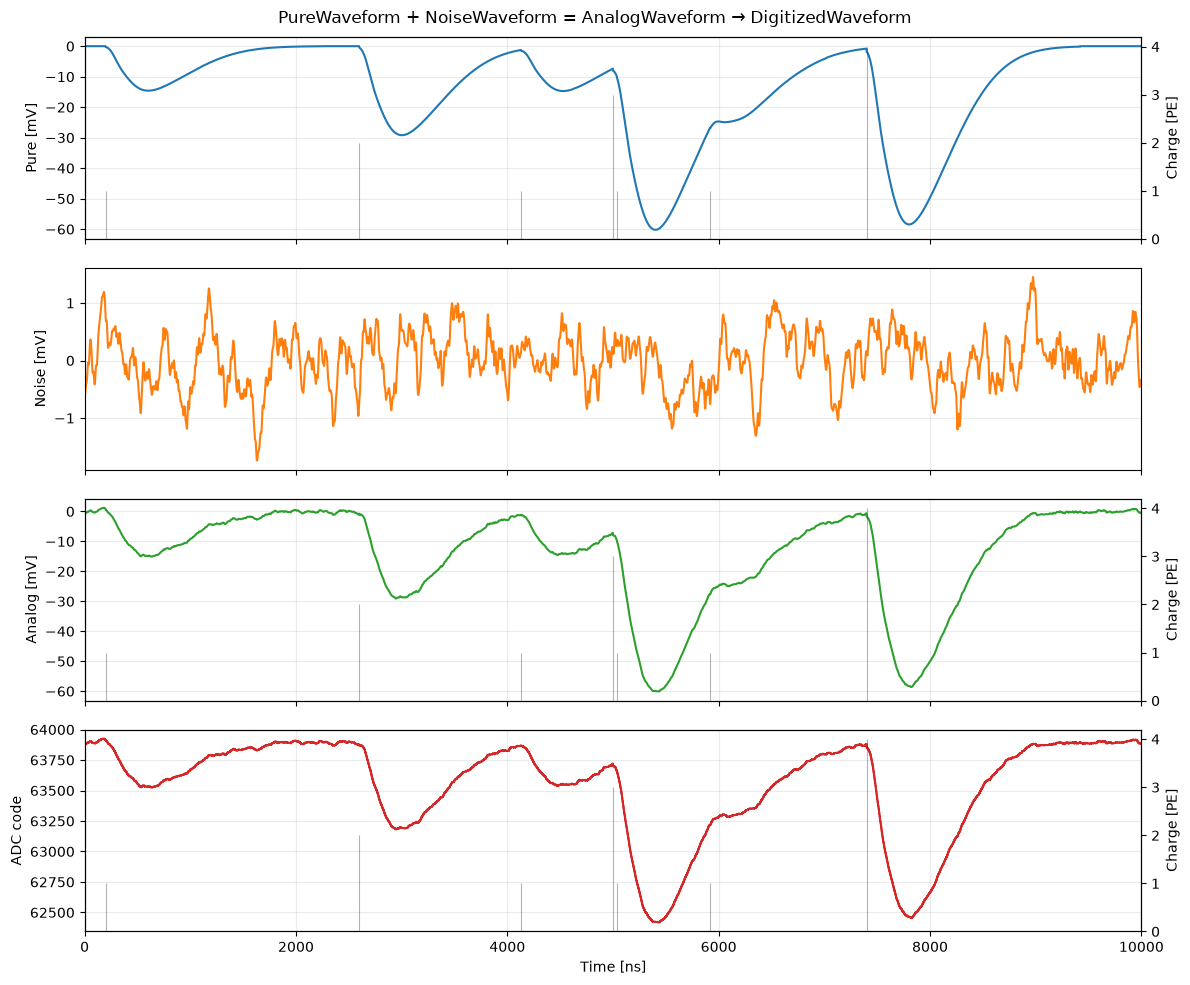

In [9]:
import matplotlib.pyplot as plt

pure = readout.field(PureWaveform)
noise = readout.field(NoiseWaveform)
analog = readout.field(AnalogWaveform)
digitized = readout.field(DigitizedWaveform)
charge = readout.field(Charge)

sample_axis = photoelectrons.axis(SampleAxis)
sample_indices = torch.arange(sample_axis.size, dtype=torch.float64)
time_ns = (sample_axis.start + sample_axis.step * sample_indices) * 1.0e-3

example_index = 0
channel_index = 0
selection = (example_index, channel_index, slice(None))

pure_trace = pure.tensor[selection].detach().cpu()
noise_trace = noise.tensor[selection].detach().cpu()
analog_trace = analog.tensor[selection].detach().cpu()
digitized_trace = digitized.tensor[selection].detach().cpu()
charge_trace = charge.tensor[selection].detach().cpu()
source_trace = photoelectrons.tensor[selection].detach().cpu()
recomposed_trace = pure_trace + noise_trace

assert torch.equal(analog_trace, recomposed_trace)
source_indices = torch.nonzero(source_trace, as_tuple=False).flatten()
charge_indices = torch.nonzero(charge_trace, as_tuple=False).flatten()
assert torch.equal(source_indices, torch.tensor((100, 1300, 2500, 3700)))
assert torch.equal(source_trace[source_indices], torch.tensor((1, 2, 3, 4)))

figure, plot_axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
plot_axes[0].plot(time_ns.numpy(), pure_trace.numpy(), color="tab:blue")
plot_axes[0].set_ylabel("Pure [mV]")
plot_axes[1].plot(time_ns.numpy(), noise_trace.numpy(), color="tab:orange")
plot_axes[1].set_ylabel("Noise [mV]")
plot_axes[2].plot(time_ns.numpy(), analog_trace.numpy(), color="tab:green")
plot_axes[2].set_ylabel("Analog [mV]")
plot_axes[3].step(time_ns.numpy(), digitized_trace.numpy(), where="post", color="tab:red")
plot_axes[3].set_ylabel("ADC code")
plot_axes[3].set_xlabel("Time [ns]")
for panel_index in (0, 2, 3):
    charge_axis = plot_axes[panel_index].twinx()
    charge_axis.vlines(
        time_ns[charge_indices].numpy(),
        0.0,
        charge_trace[charge_indices].numpy(),
        color="black",
        alpha=0.3,
        linewidth=0.8,
    )
    charge_axis.set_ylabel("Charge [PE]", color="black")
    charge_axis.tick_params(axis="y", colors="black")
    charge_axis.spines["right"].set_color("black")
    charge_axis.set_ylim(bottom=0.0)
    charge_axis.grid(False)
plot_axes[3].set_xlim(0.0, sample_axis.stop_time.magnitude * 1.0e-3)
for axis in plot_axes:
    axis.grid(alpha=0.25)
figure.suptitle("PureWaveform + NoiseWaveform = AnalogWaveform → DigitizedWaveform")
figure.tight_layout()
plt.show()
plt.close(figure)

## Request and retain one downstream product

Requesting only `DigitizedWaveform` still executes its required Charge, Pure, Noise, and Analog prerequisites. Those intermediates are validated but not retained. The resulting collection therefore contains exactly one field type, demonstrating that execution closure and public retention are distinct contracts.

In [10]:
digitized_only = simulate_readout(
    photoelectrons,
    products=(DigitizedWaveform,),
    config=ds20k_veto(),
    rng=Threefry4x32(seed=17),
)
assert tuple(digitized_only.fields) == (DigitizedWaveform,)
print("retained", tuple(product.__name__ for product in digitized_only.fields))

retained ('DigitizedWaveform',)


## Make an explicit user-owned experiment

Profiles are immutable starting points, not mutable registries. Standard `dataclasses.replace(...)` makes an experiment explicit and local. Here the PSD model is replaced with 0.5 mV RMS white noise; no profile override engine, hidden merge, or package-owned tracking state is involved.

The experimental configuration is constructed for inspection only, so it does not replace the main profile-backed result shown above.

In [11]:
experimental_config = replace(
    profile_config,
    noise_waveform=NoiseWaveformConfig(
        model=WhiteNoiseConfig(rms=quantity(0.5, "mV"))
    ),
)
experimental_config

ReadoutConfig(charge=ChargeConfig(dark_count=DarkCountConfig(rate=<Quantity(100000.0, 'hertz')>), timing_jitter=None, correlated_avalanches=None, smearing=None), pure_waveform=PureWaveformConfig(model=VetoPduPulseConfig(gaussian_center=<Quantity(232.89, 'nanosecond')>, gaussian_width=<Quantity(507.72, 'nanosecond')>, edge_offset_1=<Quantity(-81.92, 'nanosecond')>, edge_width_1=<Quantity(147.28, 'nanosecond')>, edge_offset_2=<Quantity(-176.5, 'nanosecond')>, edge_width_2=<Quantity(45.69, 'nanosecond')>, support_time=<Quantity(2020.27, 'nanosecond')>, peak_voltage_per_photoelectron=<Quantity(14.5912372, 'millivolt')>)), noise_waveform=NoiseWaveformConfig(model=WhiteNoiseConfig(rms=<Quantity(0.5, 'millivolt')>)), analog_waveform=AnalogWaveformConfig(saturation=None), digitized_waveform=DigitizedWaveformConfig(bit_depth=PositiveInteger(value=16), input_minimum=<Quantity(-3900.0, 'millivolt')>, input_maximum=<Quantity(100.0, 'millivolt')>, analog_gain_db=NonnegativeFloat(value=3.5218)))

## Future boundaries

The synthetic `Photoelectrons` tensor stands in for a future reviewed FIL/TensorG4DS adapter. Such an adapter would own upstream data translation and construct the accepted semantic truth product before calling this workflow.

TensorML consumption is also future work. Neither integration exists or is imported here, and this notebook makes no file-format, model-input, deployment, calibration, or cross-package compatibility claim. It demonstrates only TensorDSLab's current public in-memory readout boundary.